# Attestation timings after relaying within committee - full analysis for normal nodes

#### Maria Silva, July 2025


## 1. Imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Process data

### Attestations

We are using the same data as `2.0-committee-attestations.ipynb`. So, we don't need to query it again from Xatu, and instead we are simply loading the parquet file in the `data` folder.

In [4]:
file_dir = os.path.join(repo_dir, "data", "libp2p_attestations_committee.parquet")
atts_df = pd.read_parquet(file_dir)
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207913 entries, 0 to 207912
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   slot                 207913 non-null  int64         
 1   slot_start_datetime  207913 non-null  datetime64[ns]
 2   slot_status          207913 non-null  object        
 3   node_name            207913 non-null  object        
 4   node_country         207913 non-null  object        
 5   attesting_committee  207913 non-null  object        
 6   num_obs_attes        207913 non-null  int64         
 7   attes_time_avg       207913 non-null  float64       
 8   attes_time_std       204024 non-null  float64       
 9   p0                   207913 non-null  int64         
 10  p05                  207913 non-null  int64         
 11  p10                  207913 non-null  int64         
 12  p15                  207913 non-null  int64         
 13  p20           

In [5]:
atts_df["slot"].agg(["min", "max", "count"])

min      12188549
max      12188998
count      207913
Name: slot, dtype: int64

### Relay data

Now, we are loading the data from ultrasound relay.

In [6]:
# Load raw data from ultrasound
publish_file = os.path.join(
    repo_dir, "data","relay", "ultrasoud_payload_publish_time_07_21_17_32.csv"
)
publish_df = pd.read_csv(publish_file)
# Cleanup dataset
publish_df = publish_df.sort_values("slot").rename(
    columns={"time_into_slot_before_publish_ms": "relay_published_ms"}
)
publish_df["publish_minus_received_ms"] = (
    pd.to_datetime(publish_df["time_before_publish"])
    - pd.to_datetime(publish_df["received_at"])
).dt.total_seconds() * 1000
publish_df["relay_received_ms"] = publish_df[
    "relay_published_ms"
] - publish_df["publish_minus_received_ms"].astype(int)
publish_df = publish_df[
    [
        "slot",
        "is_ultra_sound_header",
        "relay_published_ms",
    ]
]
# Print info
publish_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100258 entries, 100257 to 0
Data columns (total 3 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   slot                   100258 non-null  int64
 1   is_ultra_sound_header  100258 non-null  bool 
 2   relay_published_ms     100258 non-null  int64
dtypes: bool(1), int64(2)
memory usage: 2.4 MB


### Join datasets

Now we are joining the datasets, filtering for the slots where ultrasound provided the header and computing the attestation times since the block was published. We will also drop oversubscribed nodes.

In [7]:
print("All slots: ", atts_df[atts_df["node_type"] == "Normal"]["slot"].nunique())

df = atts_df.merge(publish_df, on="slot", how="inner")
df = df[df["node_type"] == "Normal"]
print("Slots with relay data: ", df["slot"].nunique())

df = df[df["is_ultra_sound_header"]]
print("Slots with ultrasound header: ", df["slot"].nunique())

time_cols = [c for c in df.columns if c[0] == "p"] + ["attes_time_avg"]
df[time_cols] = df[time_cols].sub(df["relay_published_ms"], axis=0)

All slots:  450
Slots with relay data:  226
Slots with ultrasound header:  199


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4776 entries, 10 to 104484
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   slot                   4776 non-null   int64         
 1   slot_start_datetime    4776 non-null   datetime64[ns]
 2   slot_status            4776 non-null   object        
 3   node_name              4776 non-null   object        
 4   node_country           4776 non-null   object        
 5   attesting_committee    4776 non-null   object        
 6   num_obs_attes          4776 non-null   int64         
 7   attes_time_avg         4776 non-null   float64       
 8   attes_time_std         4776 non-null   float64       
 9   p0                     4776 non-null   int64         
 10  p05                    4776 non-null   int64         
 11  p10                    4776 non-null   int64         
 12  p15                    4776 non-null   int64         
 13  p20  

## 3. Average attestation time since relay publish

In [9]:
print(len(df[df["attes_time_avg"]>=12000]))

33


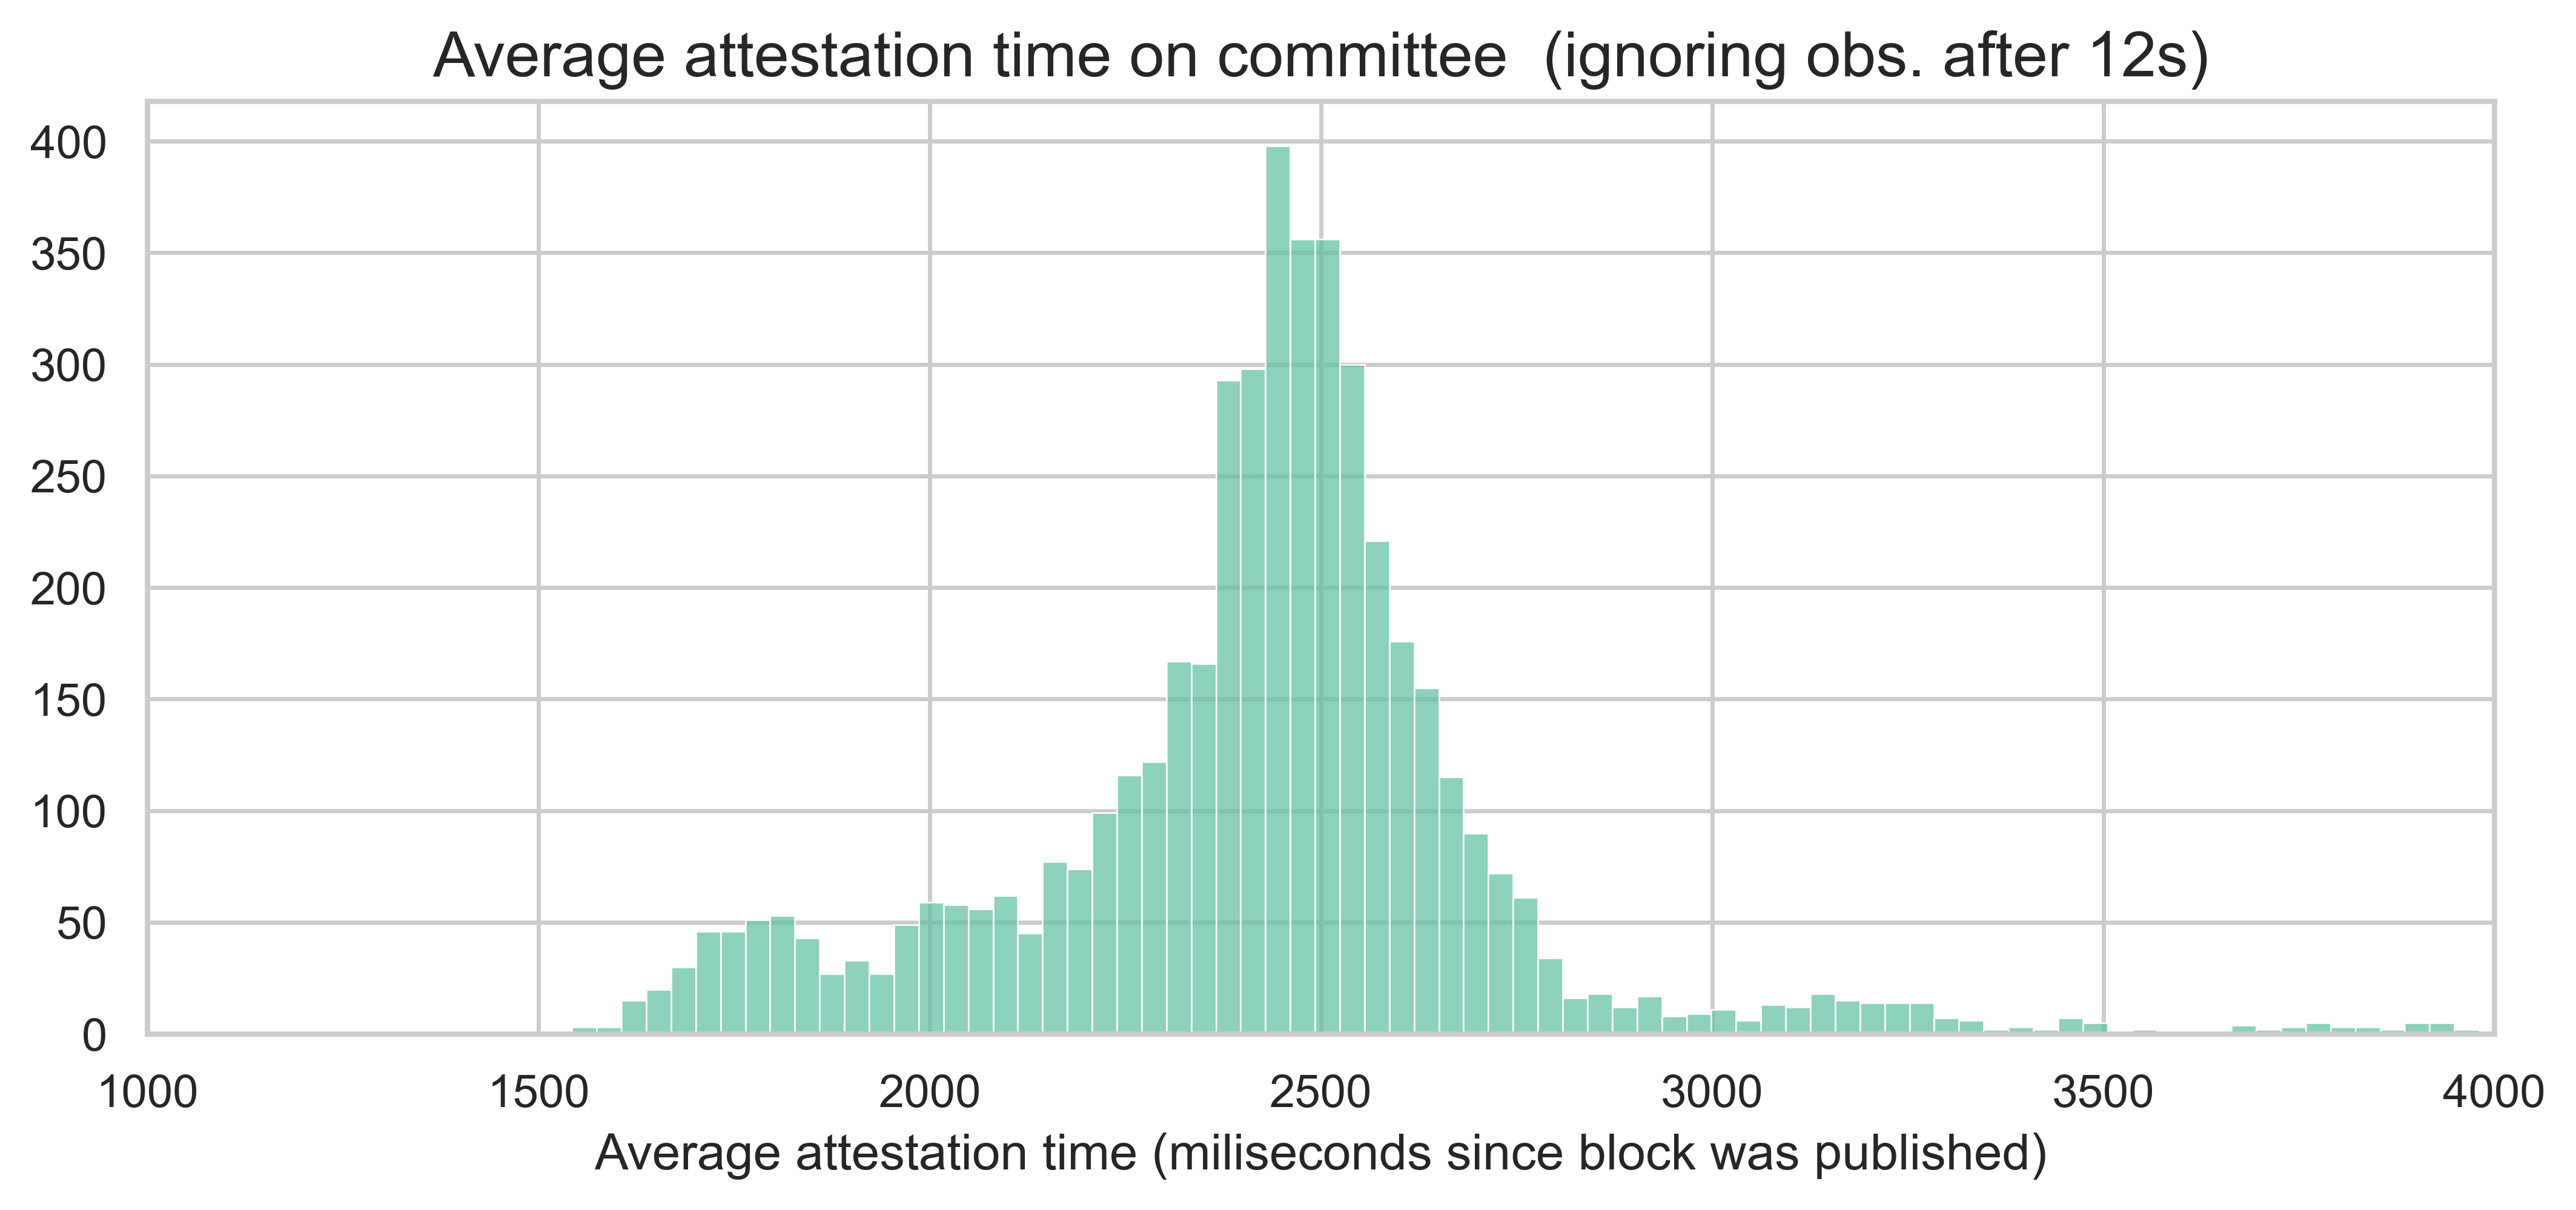

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df[df["attes_time_avg"]<12000],
    x="attes_time_avg"
)
plt.xlim(1000,4000)
plt.title("Average attestation time on committee  (ignoring obs. after 12s)")
plt.ylabel("")
plt.xlabel("Average attestation time (miliseconds since block was published)")
plt.show()

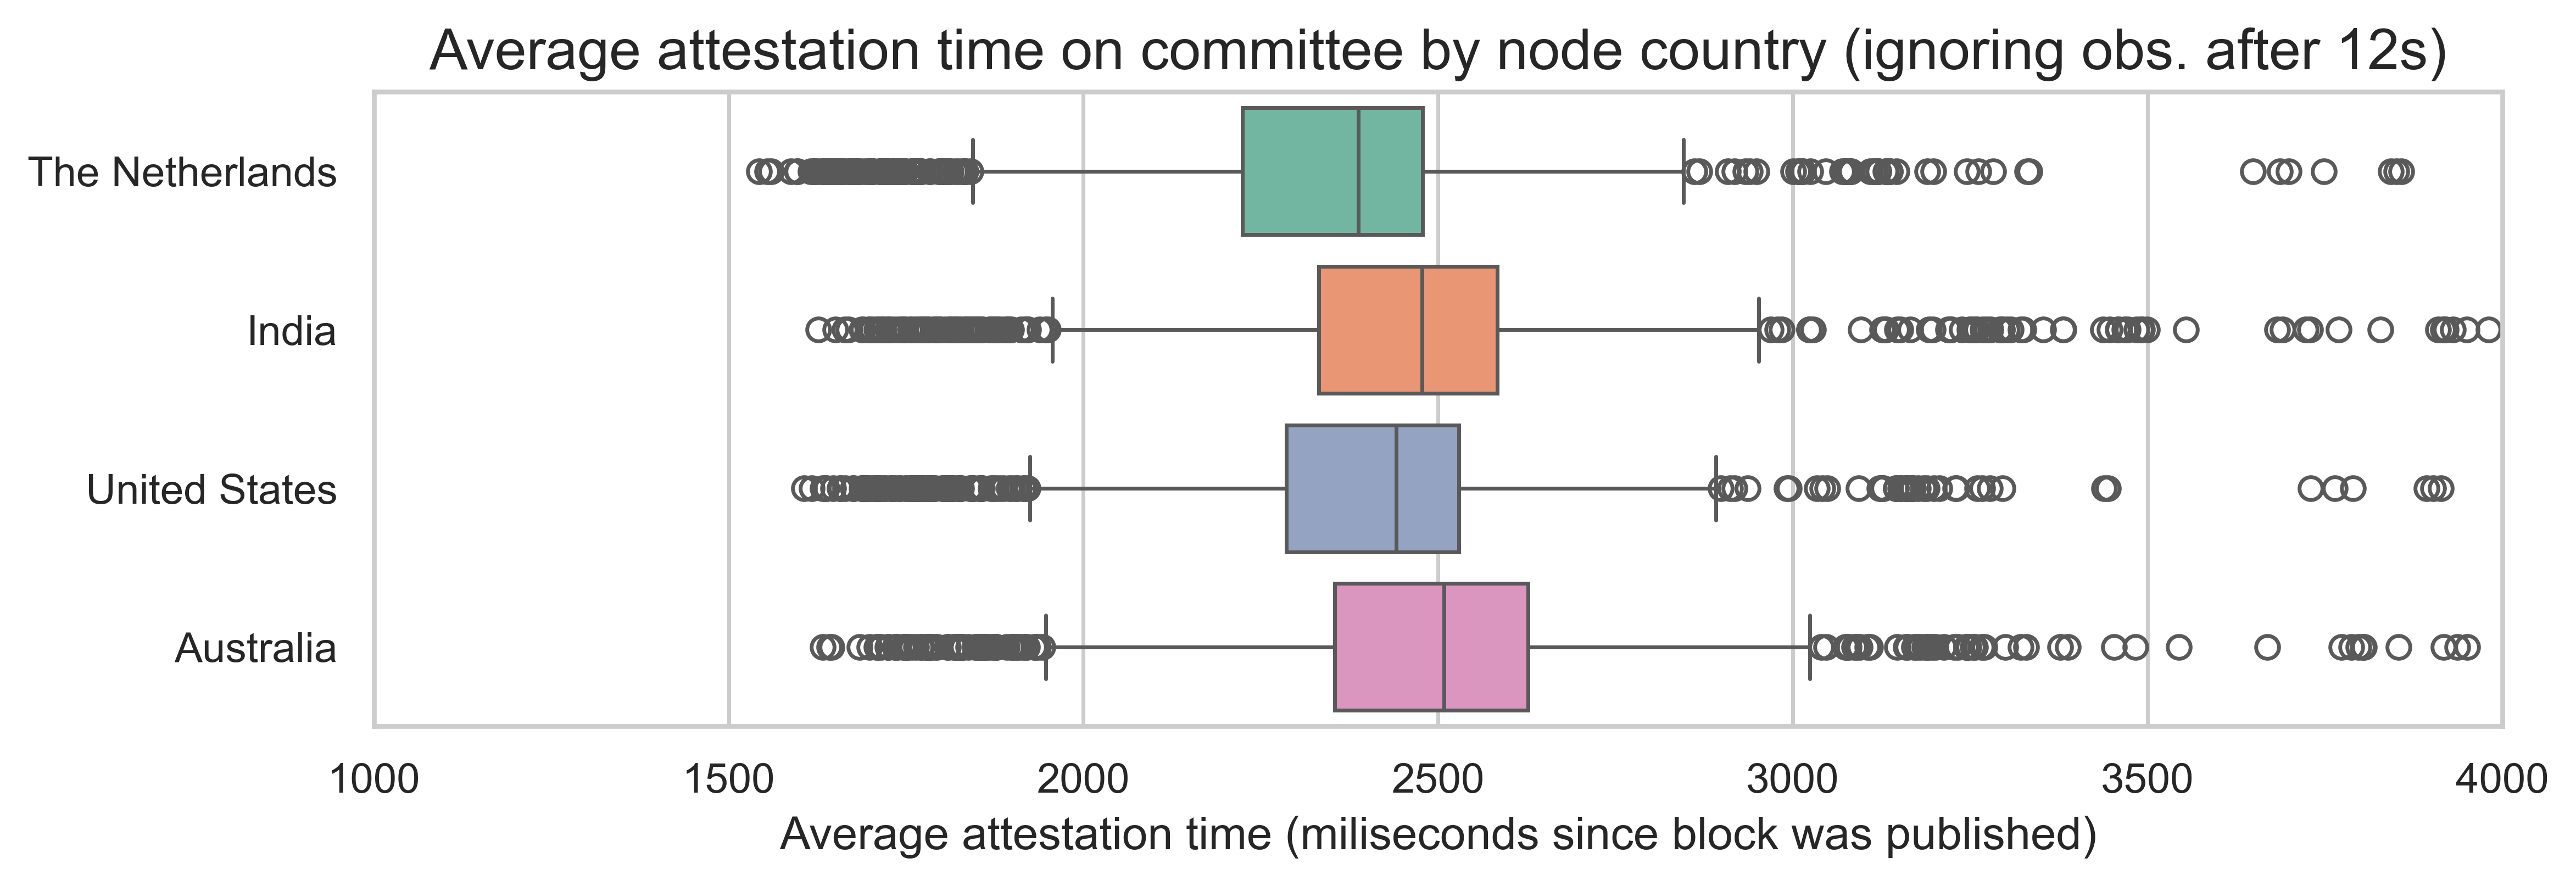

In [11]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="attes_time_avg",
    y="node_country",
    hue="node_country",
    legend=False
)
plt.xlim(1000,4000)
plt.title("Average attestation time on committee by node country (ignoring obs. after 12s)")
plt.ylabel("")
plt.xlabel("Average attestation time (miliseconds since block was published)")
plt.show()

## 4. Super-majority attestations (65%)

In [12]:
print(len(df[df["p65"]>=12000]))

0


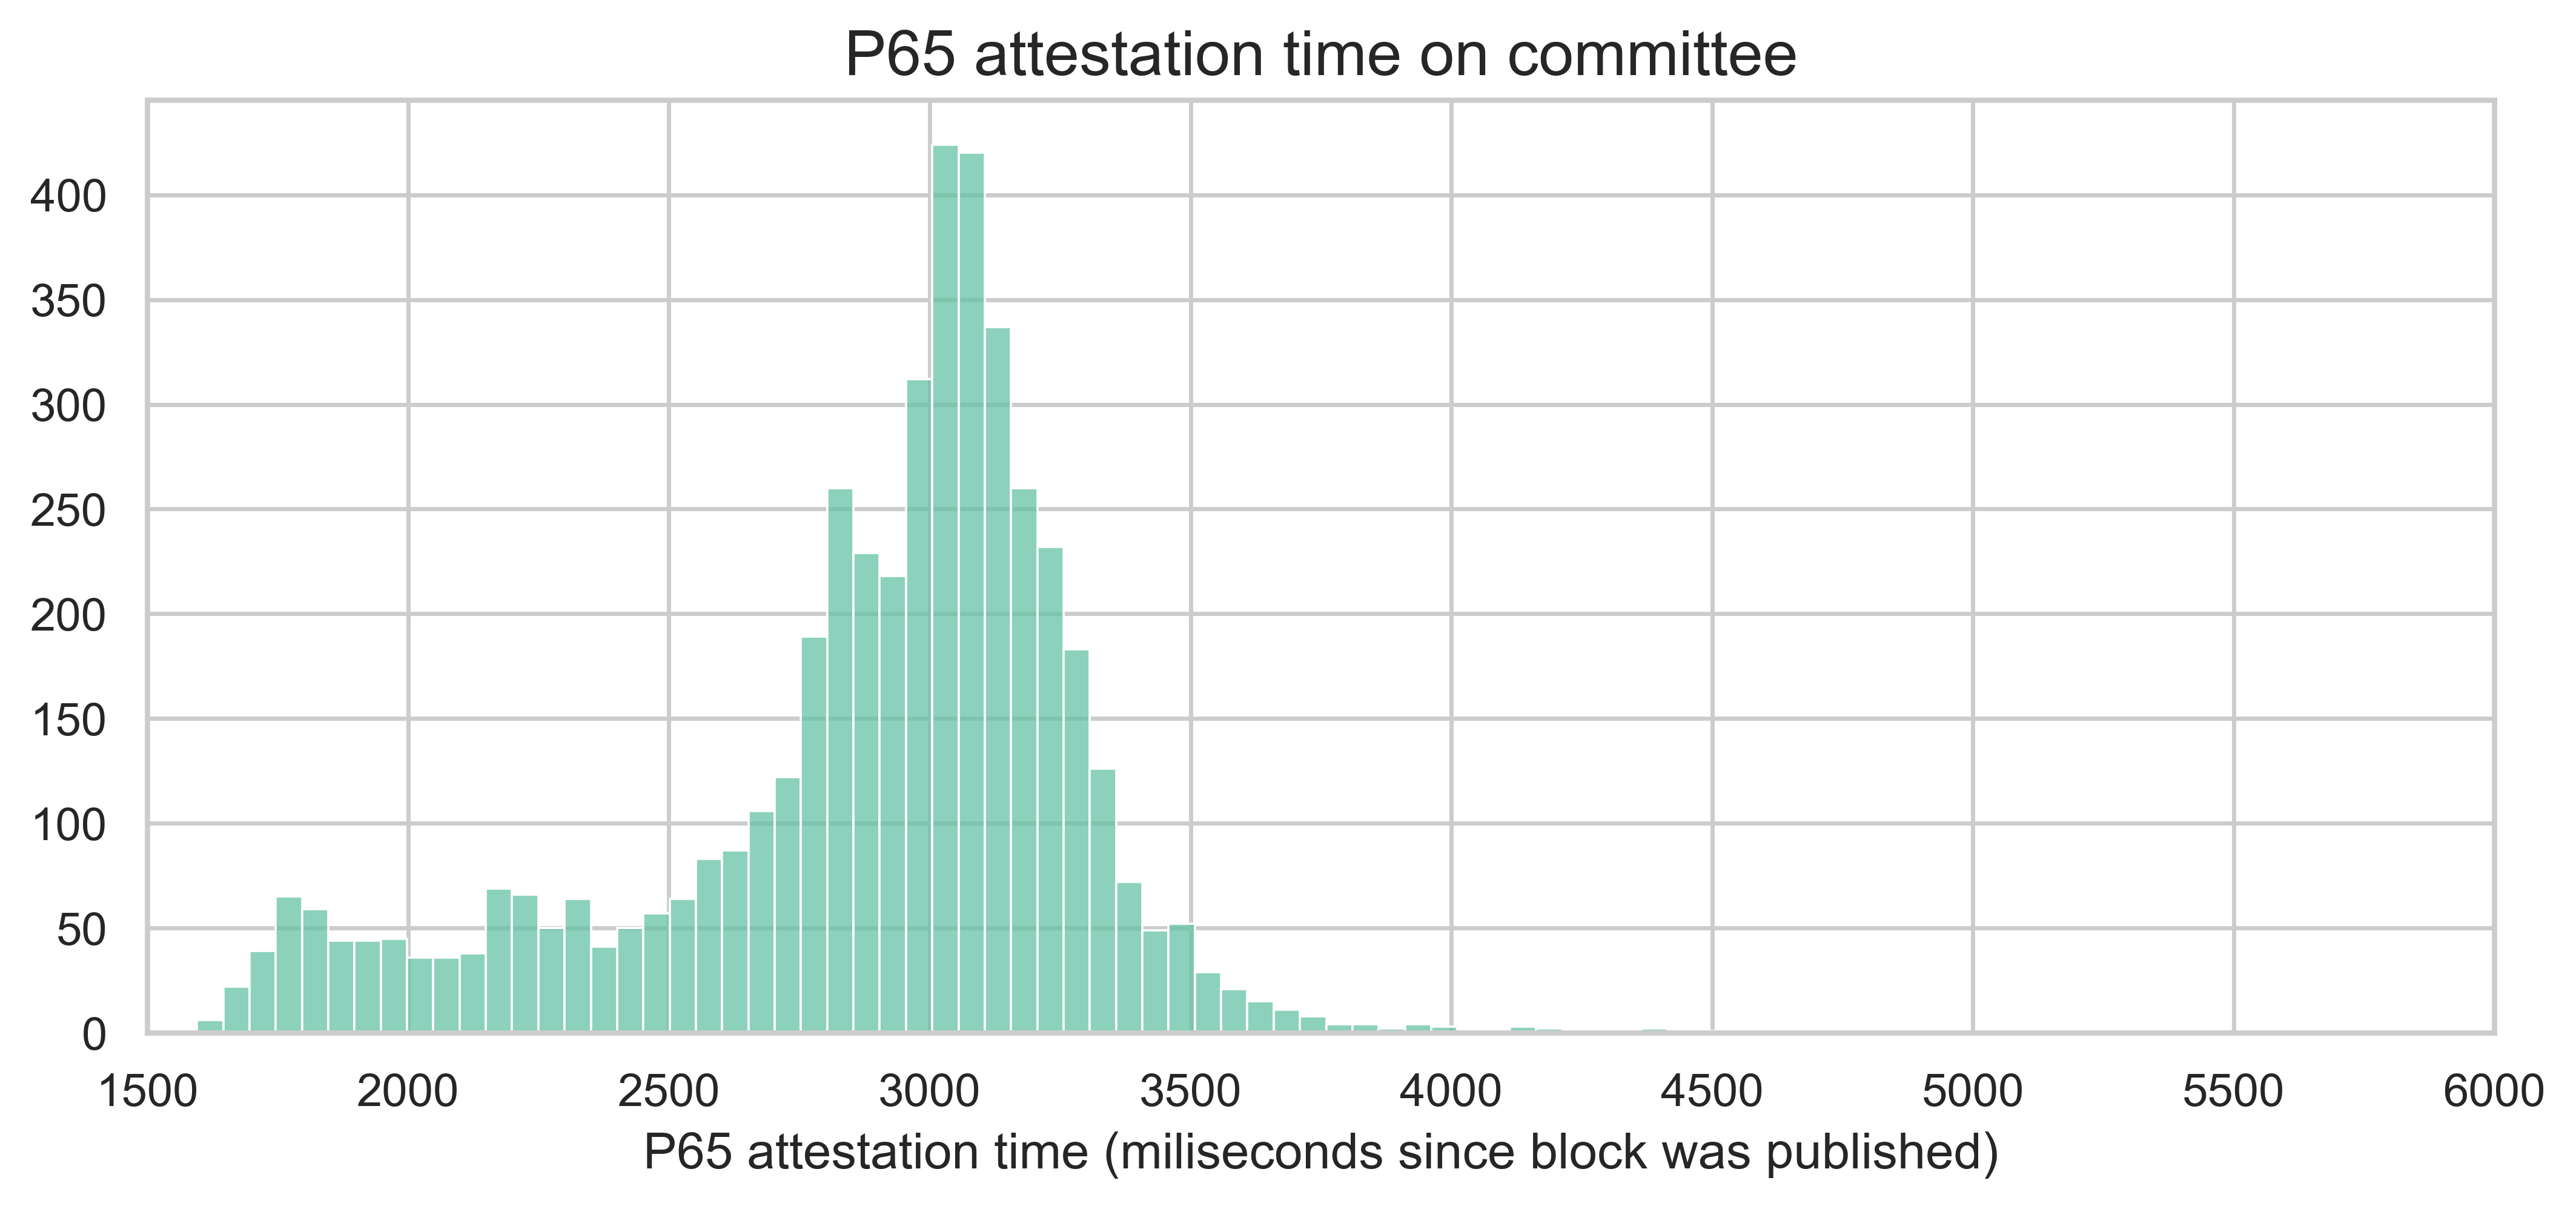

In [13]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df,
    x="p65"
)
plt.xlim(1500,6000)
plt.title("P65 attestation time on committee")
plt.ylabel("")
plt.xlabel("P65 attestation time (miliseconds since block was published)")
plt.show()

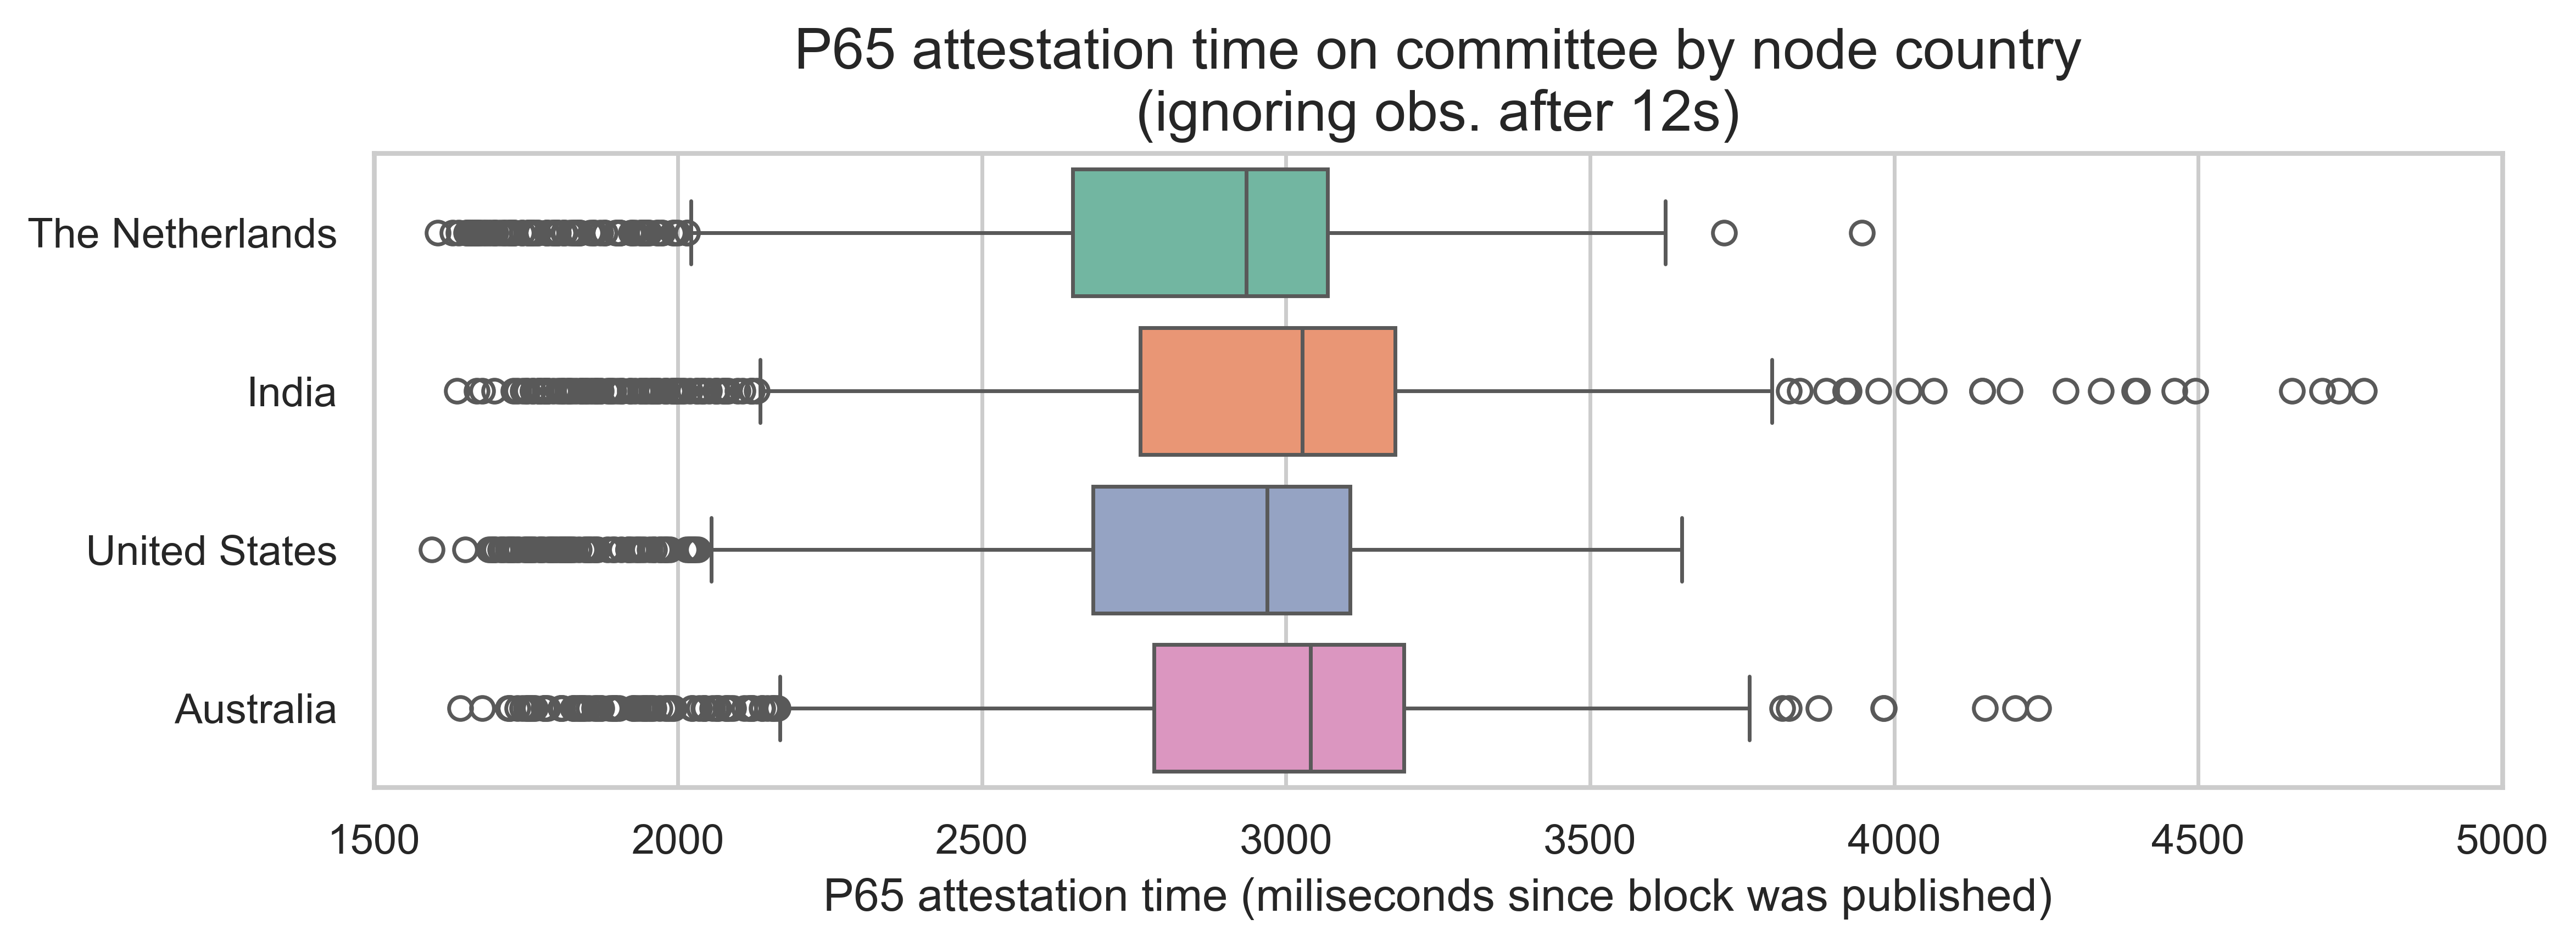

In [14]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="p65",
    y="node_country",
    hue="node_country",
    legend=False
)
plt.xlim(1500,5000)
plt.title("P65 attestation time on committee by node country\n(ignoring obs. after 12s)")
plt.ylabel("")
plt.xlabel("P65 attestation time (miliseconds since block was published)")
plt.show()

In [15]:
df["p65"].quantile([0.5, 0.8, 0.9, 0.95, 0.99])

0.50    2989.00
0.80    3180.00
0.90    3290.00
0.95    3397.00
0.99    3693.75
Name: p65, dtype: float64

## 5. P95 attestations

In [16]:
print(len(df[df["p95"]>=12000]))

0


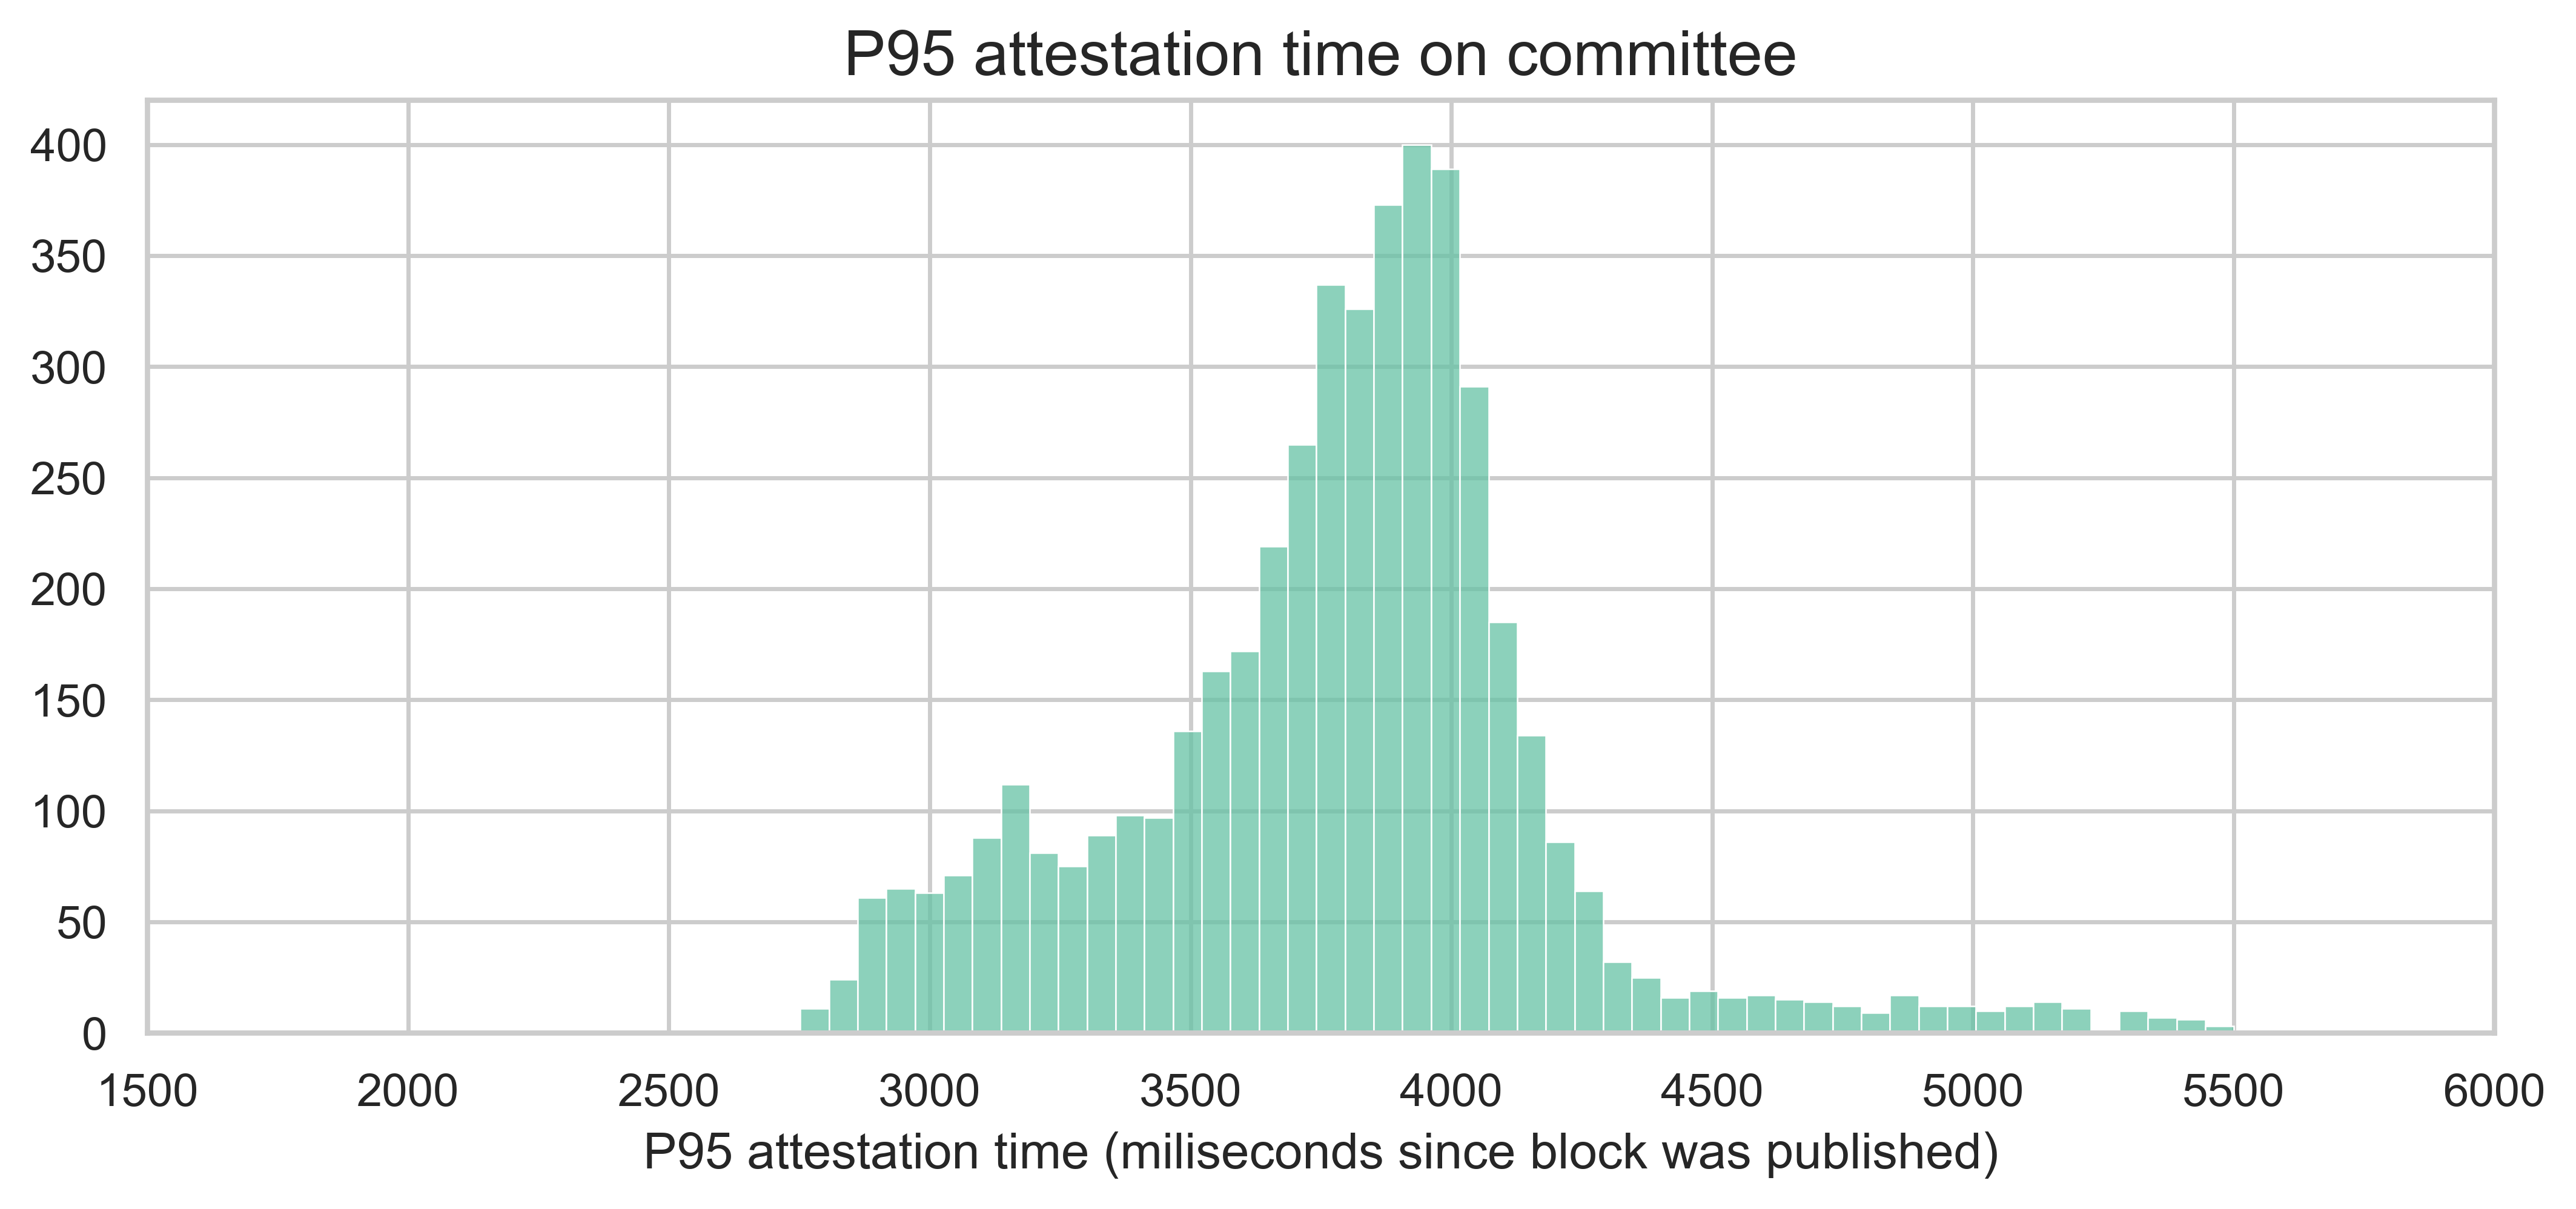

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df,
    x="p95"
)
plt.xlim(1500,6000)
plt.title("P95 attestation time on committee")
plt.ylabel("")
plt.xlabel("P95 attestation time (miliseconds since block was published)")
plt.show()

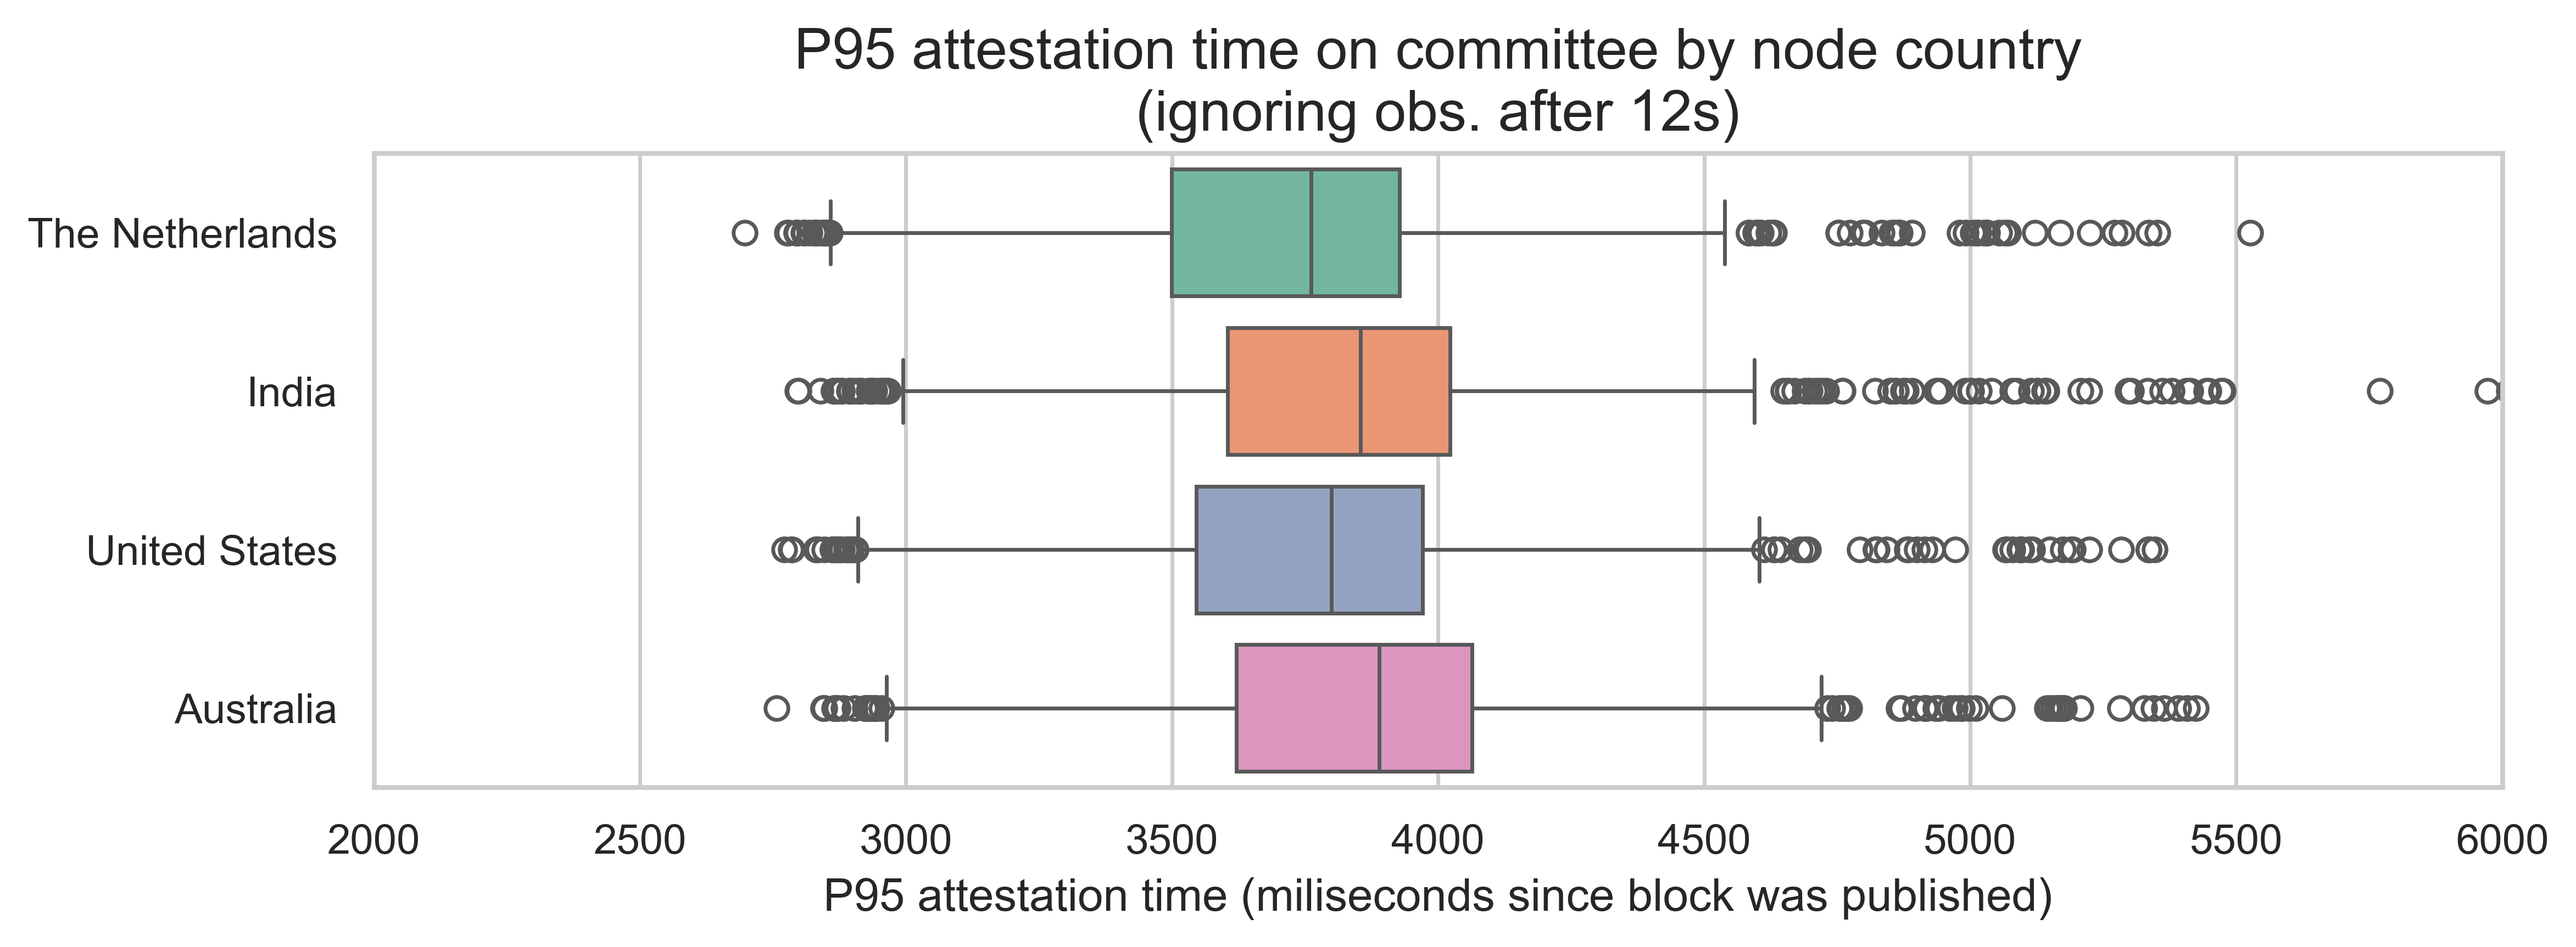

In [18]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="p95",
    y="node_country",
    hue="node_country",
    legend=False
)
plt.xlim(2000,6000)
plt.title("P95 attestation time on committee by node country\n(ignoring obs. after 12s)")
plt.ylabel("")
plt.xlabel("P95 attestation time (miliseconds since block was published)")
plt.show()

In [19]:
df["p95"].quantile([0.5, 0.8, 0.9, 0.95, 0.99])

0.50    3825.0
0.80    4036.0
0.90    4165.0
0.95    4412.5
0.99    5169.5
Name: p95, dtype: float64